# Datensatz vectara/open_ragbench

https://huggingface.co/datasets/vectara/open_ragbench

Durchführung einer Analyse des Datensatzes vectara/open_ragbench

Der Datensatz beinhaltet Paare von Fragen und dazugehörigen Referenz-Antworten, eine Sammlung der einzelnen Abschnitte der zugrundeliegenden PDF-Dokumente in strukturierter Form sowie einen Verweis der Fragen auf die Abschnitte, auf welche sich diese beziehen. Die Daten (Fragen, Antworten, PDF-URLS) werden im JSON-Format in separaten Dateien zur Verfügung gestellt.

Datensatz Pfad: vectara_open_ragbench/open_ragbench

Verzeichenis: pdf/arxiv

answers.json Antworten  
pdf_urls.json PDF-URLs  
qrels.json Beziehung zwischen Fragen und PDF-Dokumenten/URLs  
queries.json Fragen

Für jedes PDF-Dokument existiert eine Datei im JSON-Format, welche die Abschnitte der Dokumente in strukturierter Form enthalten.

Verzeichnis: pdf/arxiv/corpus

\<DOC_ID\>.json

## Setup

### Pakete laden

In [1]:
import glob
import json

import numpy as np
import pandas as pd

#import plotly.express as px
from util.px import PX

### Variablen+Funktionen

In [2]:
# Pfad zu Dateien des Datensatz
path = 'vectara_open_ragbench/open_ragbench/pdf/arxiv/'

## Daten laden

In [3]:
#glob.glob(f'{path}*')

### Antworten

In [4]:
# Datei als JSON einlesen
#f = open(f'{path}answers.json', 'r')
#data = json.load(f)
#f.close()

# JSON in Pandas DataFrame einlesen
answers = pd.read_json(
    f'{path}answers.json', orient='index', 
    dtype_backend='numpy_nullable'
).rename(columns={0: "answer"})

In [5]:
# Index auf Eindeutigkeit prüfen
answers.index.is_unique

True

In [6]:
answers

,answer
852703f0-8373-43a2-a18a-eb5908ad0779,Estimating output impedance in inverter-based ...
9199173b-3ed1-4118-88cd-1713fc5fa8a7,Increases in heterogeneity related to effectiv...
1d585069-a446-47fa-a74d-0387316ea330,Syllabic embeddings could be improved in areas...
dc064d11-cd18-4866-8a99-f16b0abec9c6,The MLMM approach affects the analysis of RMSE...
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,Uncertainty in data affects StQPs by introduci...
...,...
08a34950-7004-433d-ac0e-8c48363ce406,"Yes, the MGF can be used with complex argument..."
029ae88b-dc53-4f88-918b-c8478d7ef0d3,Cyclic graphs are used because they provide a ...
d369250a-8506-4c6c-948b-e9383e88e0e2,Adding oversampling to the molecular growth ph...
6d7c948c-4d17-4b27-bb83-eb2b88728035,Offline training of reinforcement learning age...


In [7]:
answers.info()

<class 'pandas.DataFrame'>
Index: 3045 entries, 852703f0-8373-43a2-a18a-eb5908ad0779 to 90144eed-61dd-4a4a-b85d-0e01d597004a
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   answer  3045 non-null   string
dtypes: string(1)
memory usage: 717.6 KB


## PDF Urls

In [8]:
pdf_urls = pd.read_json(
    f'{path}pdf_urls.json', orient='index', 
    dtype_backend='numpy_nullable'
).rename(columns={0: "pdf_urls"})

In [9]:
pdf_urls

,pdf_urls
2407.01528v3,https://arxiv.org/pdf/2407.01528v3
2412.00651v1,https://arxiv.org/pdf/2412.00651v1
2411.00713v1,https://arxiv.org/pdf/2411.00713v1
2411.16245v2,https://arxiv.org/pdf/2411.16245v2
2402.03953v4,https://arxiv.org/pdf/2402.03953v4
...,...
2412.20570v1,https://arxiv.org/pdf/2412.20570v1
2411.06785v2,https://arxiv.org/pdf/2411.06785v2
2403.05038v3,https://arxiv.org/pdf/2403.05038v3
2412.18346v1,https://arxiv.org/pdf/2412.18346v1


In [10]:
pdf_urls.info()

<class 'pandas.DataFrame'>
Index: 1000 entries, 2407.01528v3 to 2411.12753v2
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   pdf_urls  1000 non-null   string
dtypes: string(1)
memory usage: 60.5 KB


## Beziehungen Queries<>Dokument-Abschnitt

In [11]:
qrels = pd.read_json(
    f'{path}qrels.json', 
    orient='index', 
    dtype_backend='numpy_nullable'
)

In [12]:
qrels

,doc_id,section_id
852703f0-8373-43a2-a18a-eb5908ad0779,2410.14077v2,1
9199173b-3ed1-4118-88cd-1713fc5fa8a7,2404.00822v2,17
1d585069-a446-47fa-a74d-0387316ea330,2410.07168v2,30
dc064d11-cd18-4866-8a99-f16b0abec9c6,2401.07294v4,12
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,2411.14884v3,1
...,...,...
08a34950-7004-433d-ac0e-8c48363ce406,2410.23587v3,2
029ae88b-dc53-4f88-918b-c8478d7ef0d3,2410.12710v2,2
d369250a-8506-4c6c-948b-e9383e88e0e2,2410.10516v3,15
6d7c948c-4d17-4b27-bb83-eb2b88728035,2408.02322v2,0


In [13]:
qrels.info()

<class 'pandas.DataFrame'>
Index: 3045 entries, 852703f0-8373-43a2-a18a-eb5908ad0779 to 90144eed-61dd-4a4a-b85d-0e01d597004a
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   doc_id      3045 non-null   string
 1   section_id  3045 non-null   Int64 
dtypes: Int64(1), string(1)
memory usage: 217.1 KB


## Fragen

In [14]:
queries = pd.read_json(
    f'{path}queries.json', 
    orient='index', 
    dtype_backend='numpy_nullable'
)

In [15]:
queries

,query,type,source
852703f0-8373-43a2-a18a-eb5908ad0779,What are the challenges in estimating output i...,abstractive,text-image
9199173b-3ed1-4118-88cd-1713fc5fa8a7,How do changes in effective microbial death ra...,abstractive,text
1d585069-a446-47fa-a74d-0387316ea330,In what areas do syllabic embeddings show pote...,abstractive,text-table
dc064d11-cd18-4866-8a99-f16b0abec9c6,How does the MLMM approach affect the analysis...,abstractive,text-image
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,How does uncertainty in data affect standard q...,abstractive,text
...,...,...,...
08a34950-7004-433d-ac0e-8c48363ce406,Can the MGF be used with complex arguments?,extractive,text
029ae88b-dc53-4f88-918b-c8478d7ef0d3,Why are cyclic graphs used in studying discret...,abstractive,text-image
d369250a-8506-4c6c-948b-e9383e88e0e2,What impact does adding oversampling to the mo...,abstractive,text
6d7c948c-4d17-4b27-bb83-eb2b88728035,What challenges do reinforcement learning agen...,abstractive,text


In [16]:
queries.info()

<class 'pandas.DataFrame'>
Index: 3045 entries, 852703f0-8373-43a2-a18a-eb5908ad0779 to 90144eed-61dd-4a4a-b85d-0e01d597004a
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   3045 non-null   string
 1   type    3045 non-null   string
 2   source  3045 non-null   string
dtypes: string(3)
memory usage: 495.9 KB


In [17]:
#queries.merge(qrels, how='left', left_index=True, right_index=True)

## Explorativen Datenanalyse

Prüfung der Qualität (Eindeutigkeit, Vollständigkeit etc.) für Fragen, Antworten und Abschnitte.

Berechnung statistischer Kennzahlen zu Fragen, Antworten, Abschnitten (Gesamtzahl, Eindeutige Werte, Häufigkeiten etc.) für Datensatz und Merkmale (Anzahl Zeichen/Wörter)

In [18]:
print(f'Anzahl Fragen: {queries.shape[0]}')
print(f'Anzahl eindeutiger Fragen: {queries["query"].unique().shape[0]}')
print(f'Anzahl Antworten: {answers.shape[0]}')
print(f'Anzahl eindeutiger Antworten: {answers["answer"].unique().shape[0]}')
print(f'Anzahl Fragen-Referenzen: {qrels.shape[0]}')
print(f'Eindeutige Anzahl referenzierter Dokumente: {qrels["doc_id"].unique().shape[0]}')
#print(qrels.index.unique().shape[0])

Anzahl Fragen: 3045
Anzahl eindeutiger Fragen: 3043
Anzahl Antworten: 3045
Anzahl eindeutiger Antworten: 2744
Anzahl Fragen-Referenzen: 3045
Eindeutige Anzahl referenzierter Dokumente: 396


Der Datensatz umfasst insgesamt 3045 Paare von Fragen und dazugehörigen Referenz-Antworten, von denen 3043 Fragen und 2744 Antworten eindeutig sind und welche sich auf insgesamt 396 Dokumente beziehen. Zudem beinhaltet er eine Sammlung der einzelnen Abschnitte der zugrundeliegenden PDF-Dokumente in strukturierter Form sowie Verweise der Fragen auf die Abschnitte, auf welche sich diese beziehen. Die Daten werden im JSON-Format in separaten Dateien zur Verfügung gestellt.

In [19]:
# fehlende Werte prüfen
queries.isna().any().any() or queries.eq("").any().any()

np.False_

In [20]:
# Absolute Häufigkeiten der einzelnen Fragen (Top-Five)
queries['query'].value_counts().reset_index().iloc[:5]

,query,count
0,What is the role of neural operators in MRI re...,2
1,What is the switcher average treatment effect ...,2
2,What are the challenges in estimating output i...,1
3,How do changes in effective microbial death ra...,1
4,In what areas do syllabic embeddings show pote...,1


### Anzahl Fragen/Dokument

In [21]:
# Absolute Häufigkeiten der referenzierten Dokumente (Top-Ten)
qrels_doc_id_value_counts = qrels['doc_id'].value_counts()

qrels_doc_id_value_counts.reset_index().iloc[:10]

,doc_id,count
0,2410.14077v2,10
1,2401.07294v4,10
2,2410.11774v2,10
3,2406.17972v3,10
4,2412.10128v2,10
5,2412.15239v2,10
6,2412.10243v3,10
7,2411.13384v2,10
8,2408.04307v3,10
9,2405.17070v2,10


In [22]:
print(f'Duchschnittliche Anzahl Fragen pro Dokument:{np.array(qrels_doc_id_value_counts.values).mean()}')

Duchschnittliche Anzahl Fragen pro Dokument:7.6893939393939394


In [23]:
pd.Series(qrels_doc_id_value_counts.values).describe()

count       396.0
mean     7.689394
std      2.618723
min           1.0
25%           6.0
50%           9.0
75%          10.0
max          10.0
dtype: double[pyarrow]

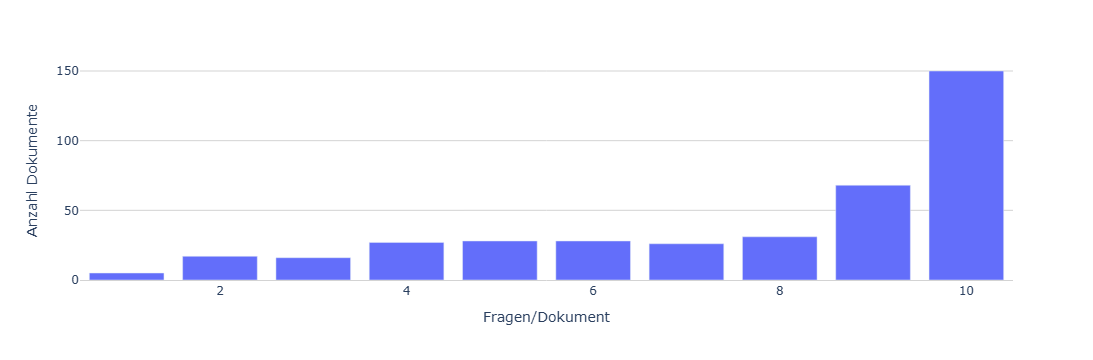

In [24]:
#PX.hist(qrels_doc_id_value_counts.values, xaxes = {'title': 'Anzahl Fragen/Dokument'}, yaxes = {'title': 'Anzahl Dokumente'})

# Werte für qrels doc_id value_counts zählen
qrels_doc_id_value_counts_counts = qrels_doc_id_value_counts.value_counts()

PX.bar(pd.DataFrame.from_dict({'x':qrels_doc_id_value_counts_counts.index.tolist(), 'y': qrels_doc_id_value_counts_counts.values.tolist()}), xaxes = {'title': 'Fragen/Dokument'}, yaxes = {'title': 'Anzahl Dokumente'}, x='x', y='y')

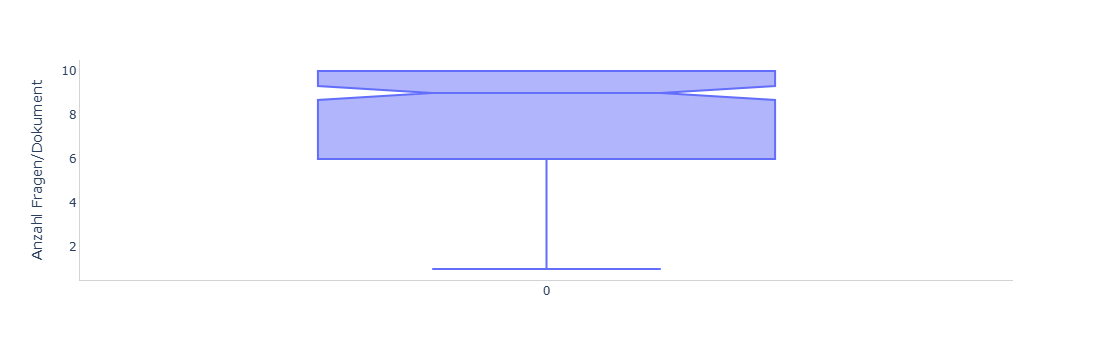

In [25]:
PX.box(qrels_doc_id_value_counts.values, xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Fragen/Dokument'})

Auf 150 der insgesamt 396 eindeutigen Dokumente, ca. 37.9%, beziehen sich jeweils 10 Fragen.  

### Anzahl Zeichen+Wörter/Frage

In [26]:
# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
queries['query_replace'] = queries['query'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
# Anzahl Wörter
queries['query_word_count'] = queries['query_replace'].str.split(' ').str.len()#r'\p{Zs}+', regex=True
# Anzahl Zeichen
queries['query_len'] = queries['query'].str.len()#r'\p{Zs}+', regex=True

# Anzahl eindeutiger Wörter
queries['query_word_count_distinct'] = queries['query_replace'].apply(lambda col: len(set(col.split(' '))))

#queries['query_word_countdistinct_ratio'] = queries['query'].apply(lambda col: len(set(col.split(' ')))) / queries['query'].apply(lambda col: len(col.split(' ')))
queries['query_word_count_distinct_ratio'] = queries['query_word_count_distinct'] / queries['query_word_count']

In [27]:
queries[['query_len', 'query_word_count', 'query_word_count_distinct', 'query_word_count_distinct_ratio']].describe()

,query_len,query_word_count,query_word_count_distinct,query_word_count_distinct_ratio
count,3045.0,3045.000000,3045.000000,3045.000000
mean,81.500821,12.094910,11.823974,0.980741
std,19.646993,2.900427,2.699932,0.041713
min,16.0,3.000000,3.000000,0.619048
25%,69.0,10.000000,10.000000,1.000000
50%,80.0,12.000000,12.000000,1.000000
75%,92.0,14.000000,13.000000,1.000000
max,197.0,29.000000,28.000000,1.000000


In [28]:
queries

,query,type,source,query_replace,query_word_count,query_len,query_word_count_distinct,query_word_count_distinct_ratio
852703f0-8373-43a2-a18a-eb5908ad0779,What are the challenges in estimating output i...,abstractive,text-image,What are the challenges in estimating output i...,11,79,10,0.909091
9199173b-3ed1-4118-88cd-1713fc5fa8a7,How do changes in effective microbial death ra...,abstractive,text,How do changes in effective microbial death ra...,14,90,14,1.000000
1d585069-a446-47fa-a74d-0387316ea330,In what areas do syllabic embeddings show pote...,abstractive,text-table,In what areas do syllabic embeddings show pote...,15,103,15,1.000000
dc064d11-cd18-4866-8a99-f16b0abec9c6,How does the MLMM approach affect the analysis...,abstractive,text-image,How does the MLMM approach affect the analysis...,14,81,13,0.928571
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,How does uncertainty in data affect standard q...,abstractive,text,How does uncertainty in data affect standard q...,10,77,10,1.000000
...,...,...,...,...,...,...,...,...
08a34950-7004-433d-ac0e-8c48363ce406,Can the MGF be used with complex arguments?,extractive,text,Can the MGF be used with complex arguments,8,43,8,1.000000
029ae88b-dc53-4f88-918b-c8478d7ef0d3,Why are cyclic graphs used in studying discret...,abstractive,text-image,Why are cyclic graphs used in studying discret...,10,67,10,1.000000
d369250a-8506-4c6c-948b-e9383e88e0e2,What impact does adding oversampling to the mo...,abstractive,text,What impact does adding oversampling to the mo...,16,111,16,1.000000
6d7c948c-4d17-4b27-bb83-eb2b88728035,What challenges do reinforcement learning agen...,abstractive,text,What challenges do reinforcement learning agen...,13,98,13,1.000000


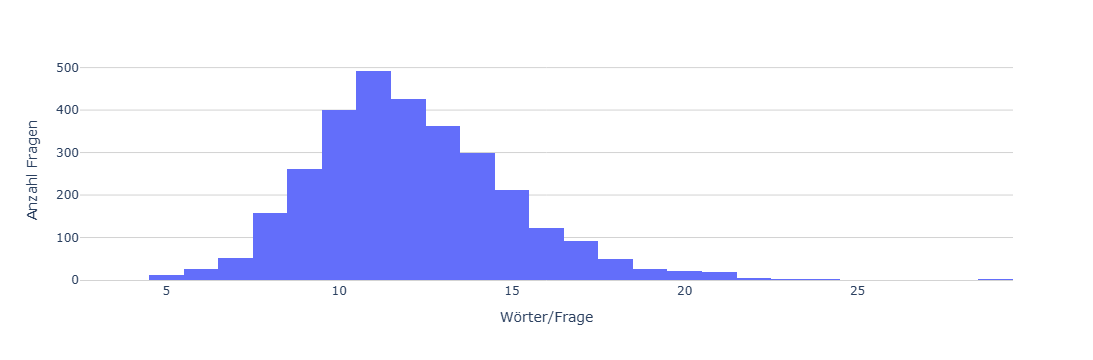

In [29]:
PX.hist(queries['query_word_count'], xaxes = {'title': 'Wörter/Frage'}, yaxes = {'title': 'Anzahl Fragen'})

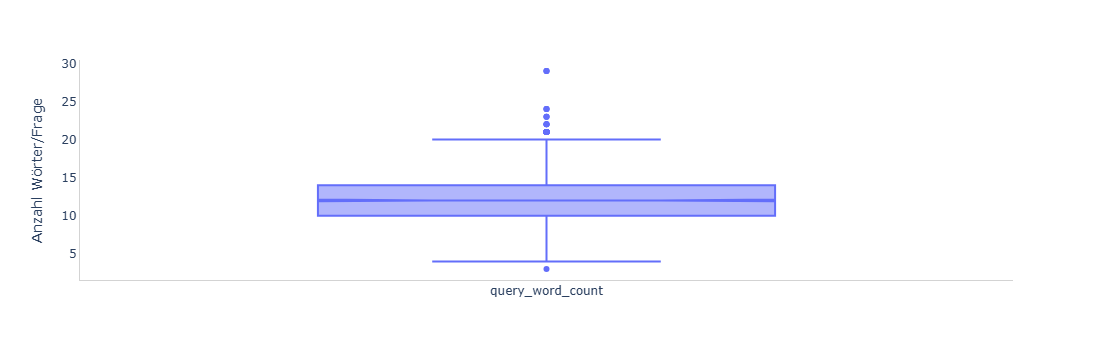

In [30]:
PX.box(queries['query_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Frage'})

In [31]:
# Wort-Anzahl Outlier (Werte kleiner untere Einzäunung)
queries.loc[queries['query_word_count'] < 4].shape[0]

1

In [32]:
# Wort-Anzahl Outlier (Werte größer obere Einzäunung)
queries.loc[queries['query_word_count'] > 20].shape[0]

31

Die Fragen bestehen im Durchschnitt sowie im Median aus ca. 12 Wörtern mit einer Standardabweichung von 2.9. Es existieren insgesamt 32 Außreißer, welche stark von der Verteilung der Anzahl der Wörter für die einzelnen Fragen abweichen. Die Anzahl der Wörter einer Frage liegt unterhalb der unteren Einzäunung von 4 Wörtern und für 31 Fragen liegt die Anzahl der Wörter über der oberen Einzäungung von 20 Wörtern.

Wie für den pdfQA-Datensatz ist das Verhältnis der eindeutigen Anzahl an Wörtern gegenüber der Gesamtzahl mit 0.981 sehr hoch sowie die Standardabweichung mit 0.042 sehr gering und der Wortschatz der Fragen weist eine hohe Diversität auf.

### Anzahl Zeichen+Wörter/Antwort

In [33]:
# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
answers['answer_replace'] = answers['answer'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
# Anzahl Wörter
answers['answer_word_count'] = answers['answer_replace'].str.split(' ').str.len()
# Anzahl Zeichen
answers['answer_len'] = answers['answer'].str.len()

# Anzahl eindeutiger Wörter
answers['answer_word_count_distinct'] = answers['answer_replace'].apply(lambda col: len(set(col.split(' '))))

#answers['answer_word_count_distinct_ratio'] = answers['answer'].apply(lambda col: len(set(col.split(' ')))) / answers['answer'].apply(lambda col: len(col.split(' ')))
answers['answer_word_count_distinct_ratio'] = answers['answer_word_count_distinct'] / answers['answer_word_count']

In [34]:
answers[['answer_len', 'answer_word_count', 'answer_word_count_distinct', 'answer_word_count_distinct_ratio']].describe()

,answer_len,answer_word_count,answer_word_count_distinct,answer_word_count_distinct_ratio
count,3045.0,3045.000000,3045.000000,3045.000000
mean,167.557635,23.174713,21.466995,0.946640
std,105.542157,14.088152,12.571085,0.064095
min,2.0,1.000000,1.000000,0.531250
25%,84.0,12.000000,12.000000,0.914286
50%,164.0,23.000000,21.000000,0.962963
75%,248.0,34.000000,31.000000,1.000000
max,687.0,90.000000,71.000000,1.000000


In [35]:
answers

,answer,answer_replace,answer_word_count,answer_len,answer_word_count_distinct,answer_word_count_distinct_ratio
852703f0-8373-43a2-a18a-eb5908ad0779,Estimating output impedance in inverter-based ...,Estimating output impedance in inverterbased g...,35,268,33,0.942857
9199173b-3ed1-4118-88cd-1713fc5fa8a7,Increases in heterogeneity related to effectiv...,Increases in heterogeneity related to effectiv...,41,296,31,0.756098
1d585069-a446-47fa-a74d-0387316ea330,Syllabic embeddings could be improved in areas...,Syllabic embeddings could be improved in areas...,28,207,28,1.000000
dc064d11-cd18-4866-8a99-f16b0abec9c6,The MLMM approach affects the analysis of RMSE...,The MLMM approach affects the analysis of RMSE...,36,240,34,0.944444
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,Uncertainty in data affects StQPs by introduci...,Uncertainty in data affects StQPs by introduci...,48,354,44,0.916667
...,...,...,...,...,...,...
08a34950-7004-433d-ac0e-8c48363ce406,"Yes, the MGF can be used with complex argument...",Yes the MGF can be used with complex arguments...,20,123,19,0.950000
029ae88b-dc53-4f88-918b-c8478d7ef0d3,Cyclic graphs are used because they provide a ...,Cyclic graphs are used because they provide a ...,38,274,36,0.947368
d369250a-8506-4c6c-948b-e9383e88e0e2,Adding oversampling to the molecular growth ph...,Adding oversampling to the molecular growth ph...,24,176,20,0.833333
6d7c948c-4d17-4b27-bb83-eb2b88728035,Offline training of reinforcement learning age...,Offline training of reinforcement learning age...,40,296,36,0.900000


In [36]:
# Absolute Häufigkeiten Antworten mit einem Wort (Top-Ten)
answers.loc[answers['answer_word_count'] == 1]['answer'].value_counts().reset_index().iloc[:10]
#answers.loc[answers['answer_word_count'] == 1]['answer'].unique()

,answer,count
0,Yes.,278
1,Yes,19
2,No.,5
3,No,2
4,Aripiprazole,1
5,https://www.pathwaycommons.org/archives/PC2/v1...,1
6,Minimax.,1
7,-0.174,1
8,Mistral-Large-2,1
9,"$2,231,356.21",1


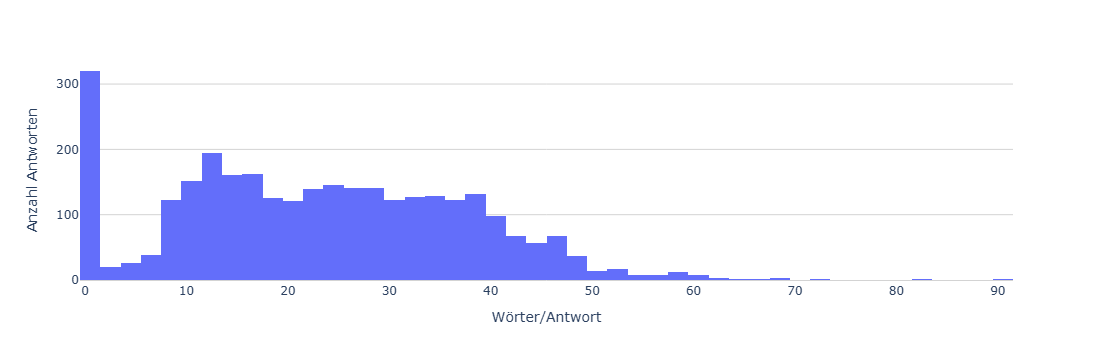

In [37]:
PX.hist(answers['answer_word_count'], xaxes = {'title': 'Wörter/Antwort'}, yaxes = {'title': 'Anzahl Antworten'})

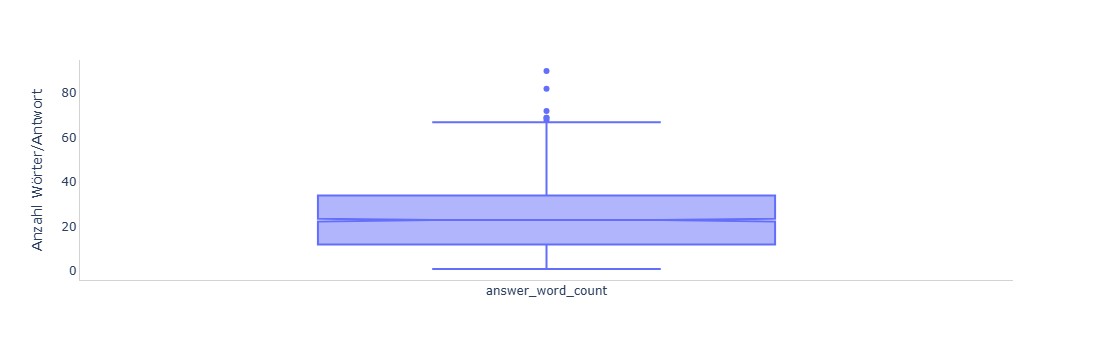

In [38]:
PX.box(answers['answer_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Antwort'})

In [39]:
# Antworten mit weniger als 8 Wörtern
answers.loc[answers['answer_word_count'] < 8, 'answer'].shape[0]#value_counts()

404

In [40]:
# Outlier (Werte größer obere Einzäunung)
answers.loc[answers['answer_word_count'] > 67, 'answer'].shape[0]

6

320 der 3045 Antworten, ca. 11%, bestehen aus nur einem Wort (davon 297 yes, 7 no), 404 Antworten besitzen 7 oder weniger Wörter.

Im Durchschnitt bestehen die Antworten aus ca. 23 Wörtern, die Standardabweichung ist mit 14.1 relativ hoch. 50% der Antworten bestehen aus 23 oder weniger Wörtern, der Interquartilsabstand, mittlere 50% der Daten, für die Verteilung der Wortanzahl beträgt 22 Wörter (75%Q 34, 25%Q 12). Die obere Einzäunung liegt bei 67 Wörtern und es gibt eine geringe Zahl von 6 Ausreißern, welche stark von der Verteilung abweichen.

Das Verhältnis der eindeutigen Wörter gegenüber der Gesamtzahl ist mit 0.947 im Durchschnitt für alle Antworten immernoch sehr hoch und die Standardabweichung mit 0.064 gering und die Werte deuten ebenso auf eine hohe Wort-Vielfalt hin.

### Queries-Source

Anzahl unterschiedlicher Source-Typen (text, text-image, text-table-image, text-table)

In [41]:
# Absolute Häufigkeiten der Fragen pro Quelle
queries_source_value_counts = queries['source'].value_counts()

queries_source_value_counts.reset_index()

,source,count
0,text,1914
1,text-image,763
2,text-table-image,220
3,text-table,148


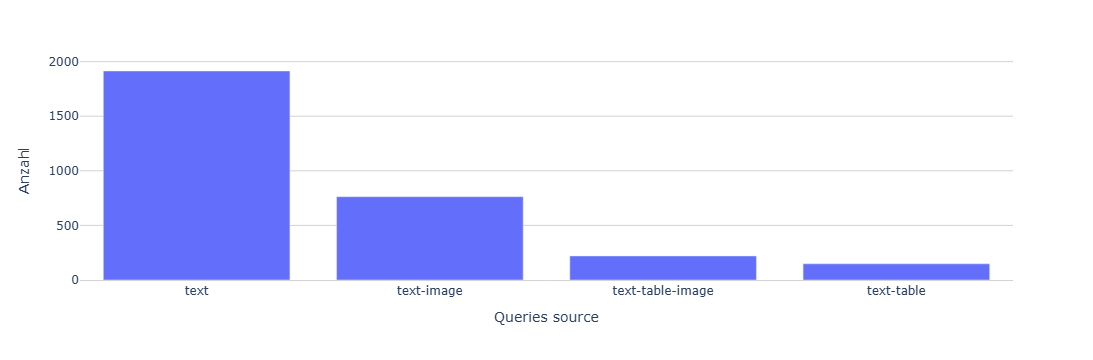

In [42]:
PX.bar(pd.DataFrame({"x": queries_source_value_counts.index.tolist(), "y": queries_source_value_counts.values.tolist()}), xaxes={'title': 'Queries source'}, yaxes={'title': 'Anzahl'})

Die Fragen sind in 4 Gruppen/Quell-Typen (text, text-image, text-table, text-table-image) unterteilt. 1914 der Fragen, ca. 63%, beziehen sich ausschließlich auf textuelle Inhalte, sowie ein geringer Teil von 148 Fragen, ca. 5%, auf Inhalte innerhalb von Tabellen. Der verbleibende Teil von 983 Fragen, ca. 32%, bezieht sich auf Inhalte innerhalb von Bildern der Dokumente.

Im geplanten System ist die Extraktion und Indizierung von textuellen Inhalten aus Bildern nicht vorgesehen. Alle Fragen des Datensatzes, welche sich auf Bilder beziehen, werden daher ausgeschlossen und für die Experimente die 2062 Fragen (text, text-table) verwendet, welche sich auf textuelle Inhalte beziehen.

### Anzahl Wörter/Antwort source='text-table'

In [43]:
queries_answers = queries.merge(answers, how='left', left_index=True, right_index=True)

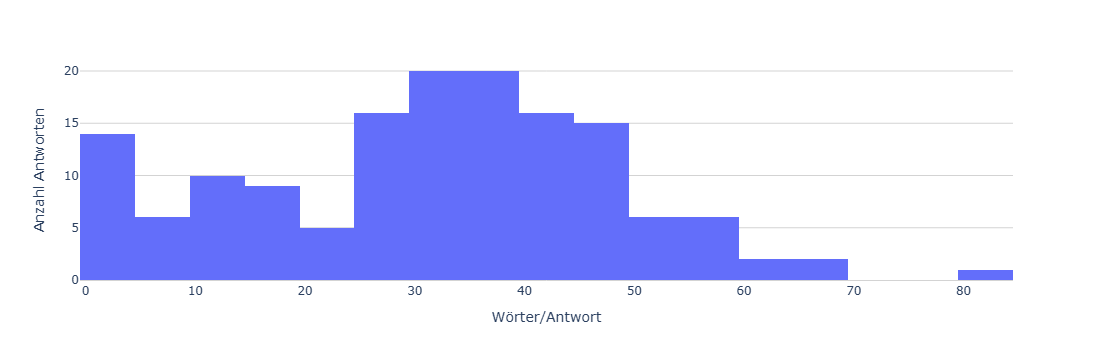

In [44]:
PX.hist(queries_answers.loc[queries_answers['source'] == 'text-table', 'answer_word_count'], xaxes = {'title': 'Wörter/Antwort'}, yaxes = {'title': 'Anzahl Antworten'})

### Queries<>Type

In [45]:
# Absolute Häufigkeiten der Fragen pro Typ
queries['type'].value_counts().reset_index()

,type,count
0,abstractive,1793
1,extractive,1252


### Queries Type by Source

In [46]:
# Absolute Häufigkeiten der Fragen pro Quelle und Typ
queries_source_group_type = queries.groupby(by=['source'], as_index=False)['type'].value_counts()

queries_source_group_type.reset_index()

,index,source,type,count
0,0,text,extractive,1021
1,1,text,abstractive,893
2,2,text-image,abstractive,630
3,3,text-image,extractive,133
4,4,text-table,abstractive,105
5,5,text-table,extractive,43
6,6,text-table-image,abstractive,165
7,7,text-table-image,extractive,55


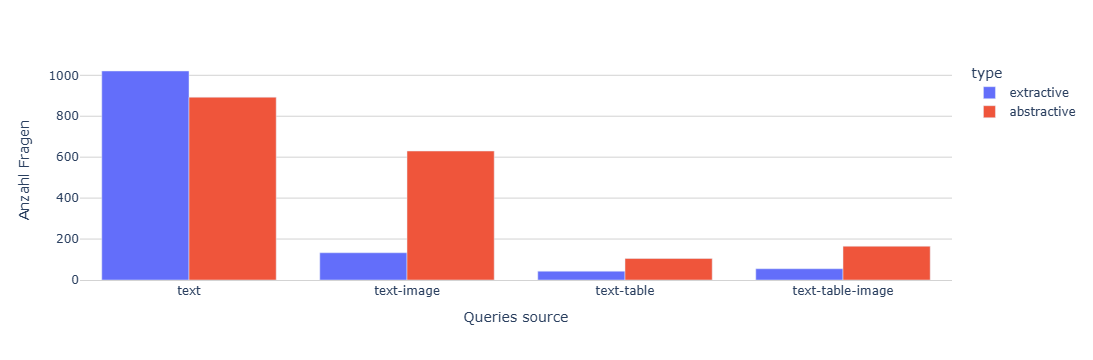

In [47]:
PX.bar(queries_source_group_type, 
       x='source', 
       y='count', 
       color='type', 
       barmode='group', 
       category_orders={'type': ['extractive', 'abstractive']}, 
       xaxes={'title': 'Queries source'}, 
       yaxes={'title': 'Anzahl Fragen'})

#### Samples text, extractive

source=text und type=extractive

In [48]:
queries.loc[(queries['source'] == 'text') & (queries['type'] == 'extractive')].sample(n=3, random_state=42)['query'].values

<ArrowStringArray>
[                                               'What happens after you initially guess a door in the Monty Hall problem?',
               'Does the sample covariance matrix have a connection with the VAR coefficient matrix in NIRVAR estimation?',
 'Does the multiscale expansion approach resolve issues with long timescale behavior in gravitational self-force studies?']
Length: 3, dtype: string

#### Samples text, abstractive

source=text und type=abstractive

In [49]:
queries.loc[(queries['source'] == 'text') & (queries['type'] == 'abstractive')].sample(n=3, random_state=42)['query'].values

<ArrowStringArray>
['What is the main difference between GFlowNet and RL in synthesis-aware molecular generation?',
                              'What type of options does the novel deep learning method price?',
                  'How does the multi-branch network architecture address imbalanced training?']
Length: 3, dtype: string

Weiterhin sind die Fragen des Datensatzes in die beiden Typen abstractive (Abstraktionsfähigkeit, das Wesentliche erfassen und unwichtige Einzelheiten weglassen) mit 1793 Einträgen und extractive (Herausziehen bestimmter Informationen) mit 1252 Einträgen unterteilt.

### Queries Source by Type

In [50]:
# Absolute Häufigkeiten der Fragen pro Typ und Quelle
queries_type_group_source = queries.groupby(by=['type'], as_index=False)['source'].value_counts()

queries_type_group_source.reset_index()

,index,type,source,count
0,0,abstractive,text,893
1,1,abstractive,text-image,630
2,2,abstractive,text-table-image,165
3,3,abstractive,text-table,105
4,4,extractive,text,1021
5,5,extractive,text-image,133
6,6,extractive,text-table-image,55
7,7,extractive,text-table,43


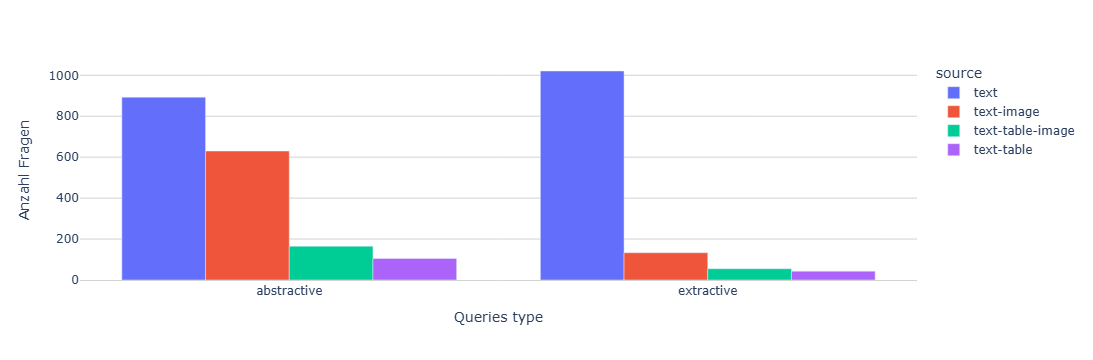

In [51]:
PX.bar(queries_type_group_source, 
       x='type', 
       y='count', 
       color='source', 
       barmode='group', 
       category_orders={'source': ['text', 'text-image', 'text-table-image', 'text-table']}, 
       xaxes={'title': 'Queries type'}, 
       yaxes={'title': 'Anzahl Fragen'})

### Anzahl Zeichen+Wörter/Antwort

Anzahl der Wörter pro Antwort für Fragen mit source=text|text-table

In [52]:
queries_source_text_table = queries.loc[(queries['source'] == 'text') | (queries['source'] == 'text-table')]

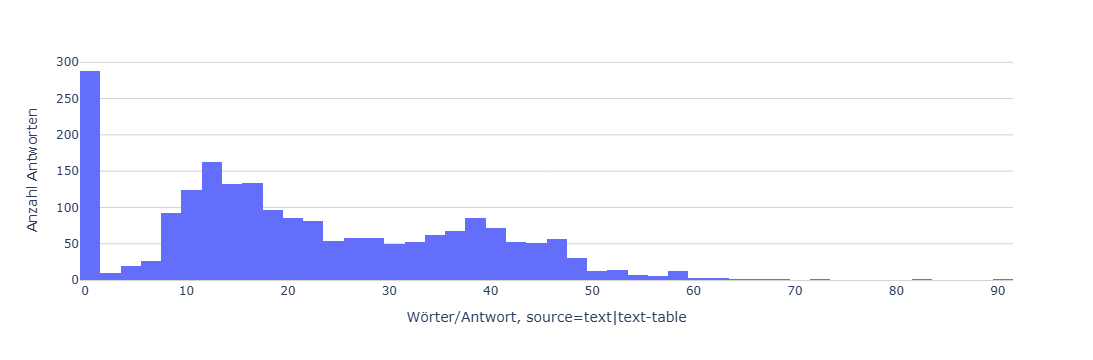

In [53]:
PX.hist(answers.loc[queries_source_text_table.index]['answer_word_count'], xaxes = {'title': 'Wörter/Antwort, source=text|text-table'}, yaxes = {'title': 'Anzahl Antworten'})

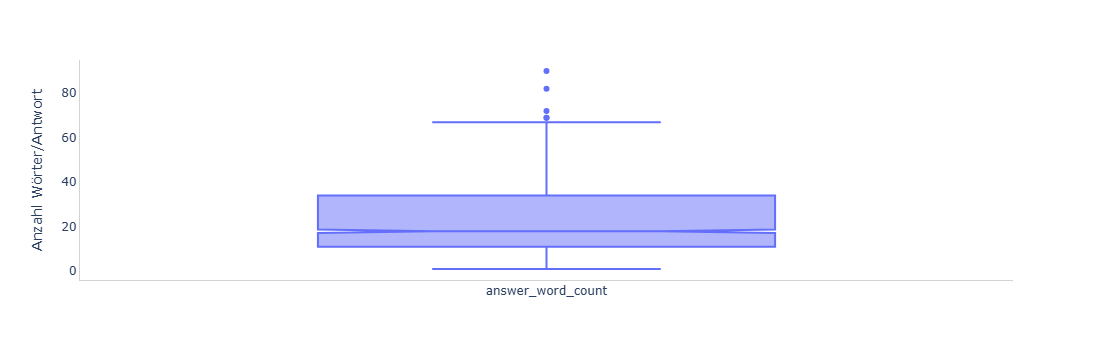

In [54]:
PX.box(answers.loc[queries_source_text_table.index]['answer_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Antwort'})

In [55]:
queries_answers = queries.merge(answers, how='inner', left_index=True, right_index=True)

In [56]:
queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table'))].shape[0]

2062

In [57]:
# Antworten mit weniger als 8 Wörtern
queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] < 8)].shape[0]

343

In [58]:
# Antworten mit mindestens 8 Wörtern
queries_answers.loc[((queries_answers['source'] == 'text') | (queries_answers['source'] == 'text-table')) & (queries_answers['answer_word_count'] >= 8)].shape[0]

1719

343 der insgesamt 2062 Fragen des Datensatzes mit Quelle (source) text oder text-table besitzen weniger als 8 Wörter. 

### Beispiel Query+Answer

Query+Answer source='text'

In [59]:
queries_source_text_table.loc[queries['source'] == 'text'].iloc[:10]

,query,type,source,query_replace,query_word_count,query_len,query_word_count_distinct,query_word_count_distinct_ratio
9199173b-3ed1-4118-88cd-1713fc5fa8a7,How do changes in effective microbial death ra...,abstractive,text,How do changes in effective microbial death ra...,14,90,14,1.000000
283afa84-f0c8-40a7-a6f1-fb2a6b97c761,How does uncertainty in data affect standard q...,abstractive,text,How does uncertainty in data affect standard q...,10,77,10,1.000000
f210906a-b4a4-4b97-84df-106214024650,How does incorporating demographic factors inf...,abstractive,text,How does incorporating demographic factors inf...,11,91,11,1.000000
a045b4ee-2986-41ce-983e-50cac2d94421,How do traditional feature selection methods f...,abstractive,text,How do traditional feature selection methods f...,9,69,9,1.000000
947fbbd3-465b-48ad-bc13-068dd830b215,How are expectations calculated in the narrati...,abstractive,text,How are expectations calculated in the narrati...,8,59,8,1.000000
1f675e98-47b5-45fc-92fa-3a7e0802d794,Does the repulsive potential affect the equili...,extractive,text,Does the repulsive potential affect the equili...,13,82,11,0.846154
6af79595-412c-4768-bf68-66ebeef9bd14,How is second-order smoothness achieved in Tik...,abstractive,text,How is secondorder smoothness achieved in Tikh...,8,67,8,1.000000
4fd3b1f4-a4f3-461f-84c8-0776c45fcae1,Does the Clayton copula exhibit dependency in ...,extractive,text,Does the Clayton copula exhibit dependency in ...,12,69,11,0.916667
af21b921-19b9-4d89-9073-a89f9f8b4be9,What is the shape of the Doppler spectrum for ...,extractive,text,What is the shape of the Doppler spectrum for ...,18,115,16,0.888889
13a9a3b6-570c-4dff-a8ab-d5777a4c487e,Does the conjecture exclude singular points of...,extractive,text,Does the conjecture exclude singular points of...,10,69,10,1.000000


In [60]:
index = 4
query = queries.loc[queries['source'] == 'text'].iloc[index]

print('query\n')
print(query['query'])
print('\n---\nanswer\n')
print(answers.loc[query.name]['answer'])

query

How are expectations calculated in the narrative framework?

---
answer

Expectations are calculated as the mean of each feature across all imagined continuations for a given chapter.


Query+Answer source='text' and type='extractive'

In [61]:
queries.loc[(queries['source'] == 'text-image') & (queries['type'] == 'extractive')].iloc[:10]

,query,type,source,query_replace,query_word_count,query_len,query_word_count_distinct,query_word_count_distinct_ratio
3c46cf58-1e36-472d-8652-8425e6360b00,What happens to coma lobes as beams move furth...,extractive,text-image,What happens to coma lobes as beams move furth...,14,76,14,1.000000
19347c88-388b-4472-927e-1933e612c9c3,What external inputs are incorporated into the...,extractive,text-image,What external inputs are incorporated into the...,10,67,10,1.000000
a511a697-8139-446c-b541-38fc89de1863,Are spurious measurements introduced in high g...,extractive,text-image,Are spurious measurements introduced in high g...,8,64,8,1.000000
8d49dc10-cee5-4e9d-b730-482c874181ff,Is there an increase in sample complexity as t...,extractive,text-image,Is there an increase in sample complexity as t...,20,109,20,1.000000
cc631a16-d651-4d3c-992f-02f6b99c0144,How is the ADO invariant defined for colored k...,extractive,text-image,How is the ADO invariant defined for colored k...,10,60,10,1.000000
1de960d9-74f6-45fa-ac7b-52b43cd32571,What is the correlation range for USD/EUR and ...,extractive,text-image,What is the correlation range for USDEUR and S...,12,69,12,1.000000
83f7512a-2555-4091-870f-a228827ef05b,Does the wireframe consist of interconnected s...,extractive,text-image,Does the wireframe consist of interconnected s...,8,63,8,1.000000
2b9ade95-c639-49e7-b9c1-afa9a8eec318,Does the gpt-4-mini model incorporate any ille...,extractive,text-image,Does the gpt4mini model incorporate any illega...,8,59,8,1.000000
73297183-6ed3-4464-96f1-c7330569813d,"Who are the developers of the ""Punch-Out!!"" VR...",extractive,text-image,Who are the developers of the PunchOut VR game,9,52,8,0.888889
6538fb0f-d563-46b6-8557-39da7cf0637f,What is the threshold difficulty value at whic...,extractive,text-image,What is the threshold difficulty value at whic...,13,85,11,0.846154


In [62]:
index = 1
query = queries.loc[(queries['source'] == 'text-image') & (queries['type'] == 'extractive')].iloc[index]

print('query\n')
print(query['query'])
print('\n---\nanswer\n')
print(answers.loc[query.name]['answer'])
print('\n---\nqrels\n')
print(qrels.loc[query.name])

#https://arxiv.org/pdf/2405.17070v2

query

What external inputs are incorporated into the final load forecast?

---
answer

The final load forecast incorporates smoothed temperatures, seasonal data, holiday information, and ETS unit root states.

---
qrels

doc_id        2405.17070v2
section_id               9
Name: 19347c88-388b-4472-927e-1933e612c9c3, dtype: object


## Dokument-Daten

Dateien mit strukturierten Daten zu PDF-Dokumenten

Für jedes PDF-Dokument des Datensatzes wird eine Datei mit struktuierten Daten, Titel, Veröffentlichungs- und letztes Aktualisierungsdatum sowie einer Liste der Abschnitte, im JSON-Format zur Verfügung gestellt.

In [63]:
#glob.glob(f'{path}corpus/*')

### Example Query<>Section relation

In [64]:
#index = 0
#query = queries.loc[queries['source'] == 'text'].iloc[index]

index = 1
query = queries.loc[(queries['source'] == 'text-image') & (queries['type'] == 'extractive')].iloc[index]

qrel = qrels.loc[query.name]

print('query\n')
print(query)
print('\n---\nqrel\n')
print(qrel)

query

query                              What external inputs are incorporated into the...
type                                                                      extractive
source                                                                    text-image
query_replace                      What external inputs are incorporated into the...
query_word_count                                                                  10
query_len                                                                         67
query_word_count_distinct                                                         10
query_word_count_distinct_ratio                                                  1.0
Name: 19347c88-388b-4472-927e-1933e612c9c3, dtype: object

---
qrel

doc_id        2405.17070v2
section_id               9
Name: 19347c88-388b-4472-927e-1933e612c9c3, dtype: object


In [65]:
# Datei einlesen
f = open(f'{path}corpus/{qrel['doc_id']}.json', 'r')
data = json.load(f)
f.close()

# Inhalt des Abschnitts ausgeben
print(data['sections'][qrel['section_id']]['text'])

## 4. Methodology
### 4.1. Modelling Concept

As detailed in Subsection 2.1, accurately forecasting load is a challenging task due to its multifaceted characteristics. Load depends on deterministic information, i.e. the seasonalities of different periods and holidays, and is sensitive to temperature fluctuations. Moreover, it is influenced by past observations. Thus, autoregressive components and non-stationary components need to be incorporated into a forecasting model. To address these diverse characteristics, we propose a two-stage GAM model integrating

[^0]
[^0]:    ${ }^{4}$ In all ETS models considered in this work, the trend component is assumed to be zero.

ETS and AR models. The general process of the model is illustrated by the flowchart in Figure 6 and described in the subsequent.

Let $Y_{t} \in \mathbb{R}$ and $X_{t}^{\text {Tonep }} \in \mathbb{R}$ be the electricity load and temperature at time $t$ for $t \in\{1, \ldots, T\}$, respectively. Additionally, we have access 

### Dokumente

Statistische Auswertung zu referenzierten Dokumenten

396 Dokumente mit Fragen

In [66]:
qrels['doc_id'].unique().shape[0]

396

In [67]:
# pdf_urls mit qrels mergen
pdf_urls_qrels = pdf_urls.merge(qrels, how='left', left_index=True, right_on='doc_id')

In [68]:
#pdf_urls_qrels.info()

In [69]:
# Dokumente mit Abschnitten
pdf_urls_qrels.loc[~pdf_urls_qrels['section_id'].isna()]['doc_id'].unique().shape[0]

396

#### JSON-Datei einlesen

JSON-Datei mit strukturierten Informationen zu Abschnitten der Dokumente einlesen

In [70]:
# Dictionary für Daten
data = {'doc_id': [], 'section': []}

# über pdf_urls iterieren
for doc_id in pdf_urls_qrels.loc[~pdf_urls_qrels['section_id'].isna()]['doc_id'].unique():
    
    f = open(f'{path}corpus/{doc_id}.json', 'r')
    doc = json.load(f)
    f.close()

    # über Abschnitte des Dokuments iterieren
    for section in doc['sections']:
        data['doc_id'].append(doc_id)
        data['section'].append(section['text'])

# Dataframe aus Dictionary erstellen
docs = pd.DataFrame.from_dict(data)

# Datentypen convertieren
docs = docs.convert_dtypes()

In [71]:
# Markdown Heandings entfernen
docs['section'] = docs['section'].str.replace(r'^#+\s', '', regex=True).str.replace(r'\n+', ' ', regex=True)

#### Anzahl Zeichen+Wörter/Abschnitt

In [72]:
# Punctuation entfernen
# Zeilenumbrüche, Tabulatoren und Leerzeichen durch Leerzeichen ersetzen
docs['section_replace'] = docs['section'].str.replace(r'\p{P}+', '', regex=True).str.replace(r'[\n\t\s]+', ' ', regex=True)
# Anzahl Wörter
docs['section_word_count'] = docs['section_replace'].str.split(' ').str.len()
# Anzahl Zeichen
docs['section_len'] = docs['section'].str.len()

# Anzahl eindeutiger Wörter
docs['section_word_count_distinct'] = docs['section_replace'].apply(lambda col: len(set(col.split(' '))))
docs['section_word_count_distinct_ratio'] = docs['section_word_count_distinct'] / docs['section_word_count']

In [73]:
docs[['section_len', 'section_word_count', 'section_word_count_distinct', 'section_word_count_distinct_ratio']].describe()

,section_len,section_word_count,section_word_count_distinct,section_word_count_distinct_ratio
count,9030.0,9030.000000,9030.000000,9030.000000
mean,3916.68804,507.107863,225.354928,0.575815
std,5217.217091,635.981758,209.720494,0.163175
min,13.0,2.000000,2.000000,0.086045
25%,1019.0,140.000000,92.000000,0.458868
50%,2294.5,309.000000,168.000000,0.557079
75%,4931.5,649.000000,299.000000,0.676647
max,86276.0,10400.000000,2808.000000,1.000000


In [74]:
docs

,doc_id,section,section_replace,section_word_count,section_len,section_word_count_distinct,section_word_count_distinct_ratio
0,2411.16245v2,Abstract Computational Fluid Dynamics (CFD) si...,Abstract Computational Fluid Dynamics CFD simu...,186,1357,128,0.688172
1,2411.16245v2,I. INTRODUCTION Computational Fluid Dynamics (...,I INTRODUCTION Computational Fluid Dynamics CF...,920,6732,497,0.540217
2,2411.16245v2,II. THEORETICAL BACKGROUND ## A. Navier-Stokes...,II THEORETICAL BACKGROUND A NavierStokes Equat...,208,1680,135,0.649038
3,2411.16245v2,B. Numerical Methods Since the Navier-Stokes e...,B Numerical Methods Since the NavierStokes equ...,463,3561,273,0.589633
4,2411.16245v2,C. Source Code Description \& Characterization...,C Source Code Description Characterization In ...,307,2038,189,0.615635
...,...,...,...,...,...,...,...
9025,2412.20570v1,A. 3 Computing boundary flux integrals We now...,A 3 Computing boundary flux integrals We now d...,586,10219,255,0.435154
9026,2412.20570v1,B Reduced ionic and voltage asymptotic formula...,B Reduced ionic and voltage asymptotic formula...,263,6121,128,0.486692
9027,2412.20570v1,B. 2 Large interior charge Alternatively if $...,B 2 Large interior charge Alternatively if $al...,656,14029,212,0.323171
9028,2412.20570v1,C Numerical solutions of electro-diffusion mod...,C Numerical solutions of electrodiffusion mode...,125,838,78,0.624000


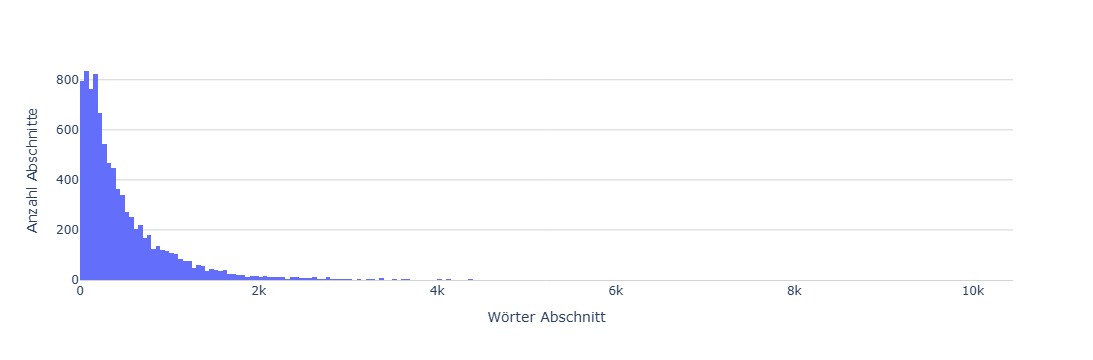

In [75]:
PX.hist(docs['section_word_count'], xaxes = {'title': 'Wörter Abschnitt'}, yaxes = {'title': 'Anzahl Abschnitte'})

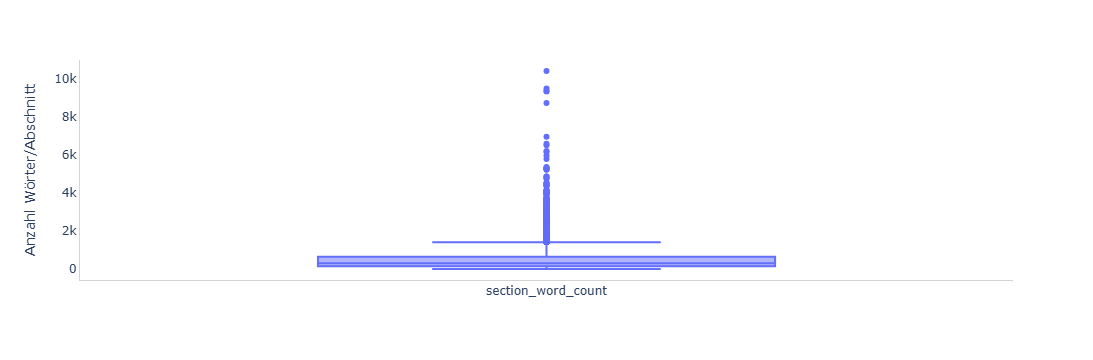

In [76]:
PX.box(docs['section_word_count'], xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Abschnitt'})

#### Anzahl Zeichen+Wörter/Abschnitte pro Dokument

In [77]:
docs_group_doc_id = docs.groupby("doc_id")

In [78]:
docs_group_doc_id['section_word_count'].sum().reset_index()

,doc_id,section_word_count
0,2401.02564v2,3989
1,2401.03305v2,11591
2,2401.03345v2,7993
3,2401.03776v8,7294
4,2401.05657v5,4104
...,...,...
391,2412.20570v1,9875
392,2412.21038v2,19331
393,2501.00225v2,14486
394,2501.00398v2,3225


In [79]:
docs_group_doc_id['section_word_count'].sum().describe()

count      396.000000
mean     11563.595960
std       7476.175412
min        992.000000
25%       6988.250000
50%      10236.000000
75%      14135.000000
max      66458.000000
Name: section_word_count, dtype: float64

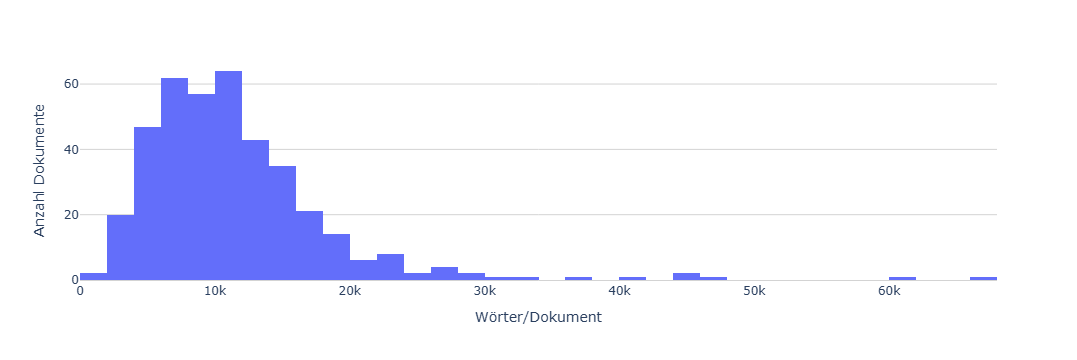

In [80]:
PX.hist(docs_group_doc_id['section_word_count'].sum(), xaxes = {'title': 'Wörter/Dokument'}, yaxes = {'title': 'Anzahl Dokumente'})

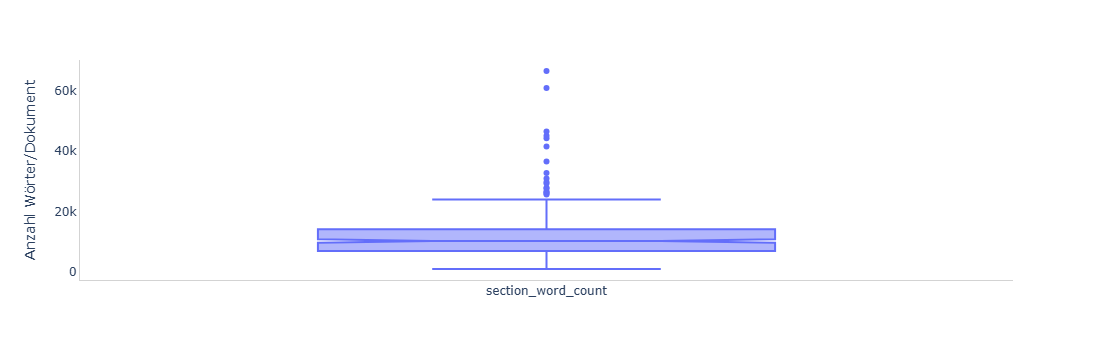

In [81]:
PX.box(docs_group_doc_id['section_word_count'].sum(), xaxes = {'title': ''}, yaxes = {'title': 'Anzahl Wörter/Dokument'})

#### Durchschnittliche Anzahl Zeichen+Wörter/Abschnitte pro Dokuments

In [82]:
docs_group_doc_id['section_word_count'].mean().reset_index()

,doc_id,section_word_count
0,2401.02564v2,265.933333
1,2401.03305v2,429.296296
2,2401.03345v2,275.620690
3,2401.03776v8,455.875000
4,2401.05657v5,586.285714
...,...,...
391,2412.20570v1,448.863636
392,2412.21038v2,715.962963
393,2501.00225v2,1316.909091
394,2501.00398v2,215.000000


In [83]:
docs_group_doc_id['section_word_count'].mean().describe()

count     396.000000
mean      625.285557
std       542.145428
min       121.476923
25%       358.911765
50%       484.084091
75%       696.072690
max      5234.500000
Name: section_word_count, dtype: float64

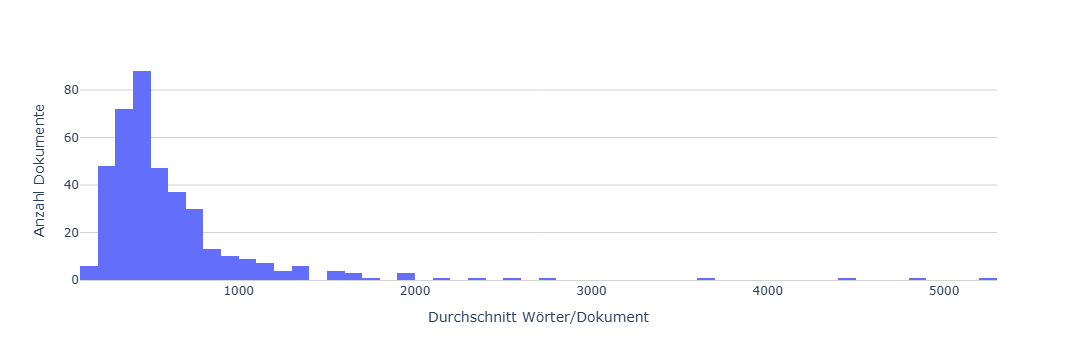

In [84]:
PX.hist(docs_group_doc_id['section_word_count'].mean(), xaxes = {'title': 'Durchschnitt Wörter/Dokument'}, yaxes = {'title': 'Anzahl Dokumente'})

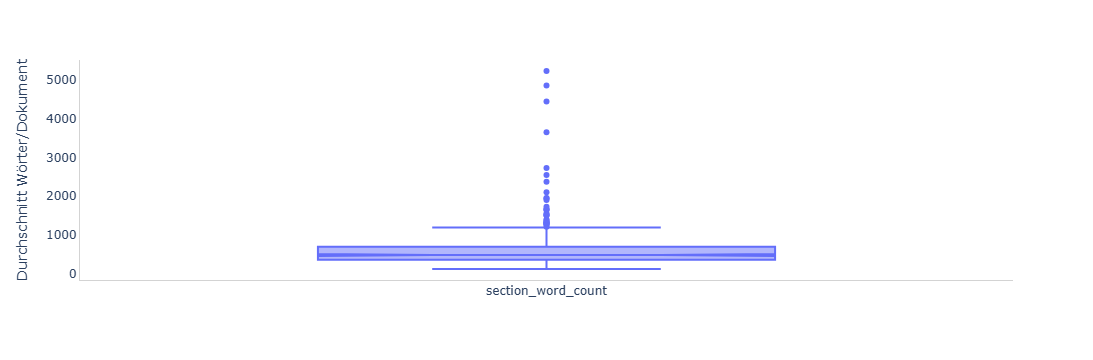

In [85]:
PX.box(docs_group_doc_id['section_word_count'].mean(), xaxes = {'title': ''}, yaxes = {'title': 'Durchschnitt Wörter/Dokument'})